# Advanced Time Series Forecasting in Retail — Model Tournament
## M5 Forecasting | CA_1 Store | FOODS_3 Department | Top 10 Items
---
**Pipeline:** Data Loading → EDA → Phase 1 (Validation) → Phase 2 (Baselines) → Phase 3 (Univariate) → Phase 4 (Multivariate) → Phase 5 (Deep Learning + ML) → Phase 6 (Tournament)

In [ ]:
#utils
import pandas as pd
import numpy as np
import warnings
import gc
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
SEED = 42
np.random.seed(SEED)

#memory
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'  Memory before: {start_mem:.2f} MB')
    for col in df.columns:
        col_type = df[col].dtype
        if pd.api.types.is_numeric_dtype(col_type):
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type).startswith('int'):
                for dtype in [np.int8, np.int16, np.int32]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype); break
            else:
                for dtype in [np.float16, np.float32]:
                    if c_min > np.finfo(dtype).min and c_max < np.finfo(dtype).max:
                        df[col] = df[col].astype(dtype); break
        elif str(col_type) in ('object', 'string') and col != 'date':
            df[col] = df[col].astype('category')
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'  Memory after:  {end_mem:.2f} MB  (reduced {100*(start_mem-end_mem)/start_mem:.1f}%)')
    return df

def calculate_metrics(y_true, y_pred, model_name, store=None):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'  {model_name:<40s}  RMSE={rmse:7.4f}   MAE={mae:7.4f}')
    if store is not None:
        store[model_name] = {'RMSE': rmse, 'MAE': mae}
    return rmse, mae


✅  Utilities loaded.


In [ ]:
#data loading
DATA_DIR = Path('data')  

df_sales    = pd.read_csv(DATA_DIR / 'sales_train_evaluation.csv')
df_calendar = pd.read_csv(DATA_DIR / 'calendar.csv')
df_prices   = pd.read_csv(DATA_DIR / 'sell_prices.csv')

id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_ts = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='sales')
del df_sales; gc.collect()

#downcasting
df_ts       = reduce_mem_usage(df_ts)
df_calendar = reduce_mem_usage(df_calendar)
df_prices   = reduce_mem_usage(df_prices)

#needed calendar columns
cal_cols = ['d', 'date', 'wm_yr_wk', 'weekday', 'month', 'year',
            'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI']
cal_cols = [c for c in cal_cols if c in df_calendar.columns]

#merge calendar
df_final = pd.merge(df_ts, df_calendar[cal_cols], on='d', how='left')
df_final['date'] = pd.to_datetime(df_final['date'].astype(str))
del df_ts; gc.collect()

#merge prices
df_final = pd.merge(df_final, df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_prices; gc.collect()

print('\nFinal schema:')
df_final.info()

Loading raw CSVs...
Melting wide → long format...
Downcasting...
  Memory before: 3612.13 MB
  Memory after:  3273.49 MB  (reduced 9.4%)
  Memory before: 0.21 MB
  Memory after:  0.12 MB  (reduced 41.9%)
  Memory before: 208.77 MB
  Memory after:  130.48 MB  (reduced 37.5%)
Merging calendar...
Merging prices...

Final schema:
<class 'pandas.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 19 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            str           
 1   item_id       str           
 2   dept_id       str           
 3   cat_id        str           
 4   store_id      str           
 5   state_id      str           
 6   d             str           
 7   sales         int16         
 8   date          datetime64[us]
 9   wm_yr_wk      int16         
 10  weekday       str           
 11  month         int8          
 12  year          int16         
 13  event_name_1  str           
 14  event_type_1  str  

In [ ]:
#scope + chronological split

#restrict to CA_1 / FOODS_3
df_ca1 = df_final[(df_final['store_id'] == 'CA_1') &
                  (df_final['dept_id']  == 'FOODS_3')].copy()

df_ca1['day_num'] = df_ca1['d'].str.replace('d_', '', regex=False).astype(int)

#save a global df to train the LSTM
LSTM_COLS = ['item_id', 'day_num', 'date', 'sales', 'snap_CA', 'event_name_1']
df_ca1['day_num'] = df_ca1['d'].str.replace('d_', '', regex=False).astype(int)
df_global_lstm = (
    df_final[df_final['store_id'] == 'CA_1']
    .copy()
)
df_global_lstm['day_num'] = df_global_lstm['d'].str.replace('d_', '', regex=False).astype(int)
df_global_lstm = df_global_lstm[LSTM_COLS].copy()
df_global_lstm['date'] = pd.to_datetime(df_global_lstm['date'].astype(str))
n_global = df_global_lstm['item_id'].nunique()
print(f'  df_global_lstm: {n_global} unique items across all CA_1 departments')

#Top-10 by total training-period sales (days 1–1885 only)
top_10_items = (
    df_ca1[df_ca1['day_num'] <= 1885]
    .groupby('item_id')['sales'].sum()
    .nlargest(10).index.tolist()
)
print(f'\nTop-10 items: {top_10_items}')

df_models = df_ca1[df_ca1['item_id'].isin(top_10_items)].copy()
del df_ca1, df_final; gc.collect()

#chronological split
TRAIN_END = 1885
VAL_START, VAL_END   = 1886, 1913
TEST_START, TEST_END = 1914, 1941

train = df_models[df_models['day_num'] <= TRAIN_END].copy()
val   = df_models[(df_models['day_num'] >= VAL_START)  & (df_models['day_num'] <= VAL_END)].copy()
test  = df_models[(df_models['day_num'] >= TEST_START) & (df_models['day_num'] <= TEST_END)].copy()

print(f'\nTRAIN  (days   1–{TRAIN_END}): {len(train):>8,} rows')
print(f'VAL    (days {VAL_START}–{VAL_END}): {len(val):>8,} rows')
print(f'TEST   (days {TEST_START}–{TEST_END}): {len(test):>8,} rows')

results_val  = val[['item_id', 'd', 'day_num', 'date', 'sales']].rename(columns={'sales': 'y_true'}).copy()
results_test = test[['item_id', 'd', 'day_num', 'date', 'sales']].rename(columns={'sales': 'y_true'}).copy()

metrics_val  = {}   
metrics_test = {}


PHASE 1 — VALIDATION STRATEGY & DATA LEAKAGE PREVENTION
  df_global_lstm: 3049 unique items across all CA_1 departments

Top-10 items: ['FOODS_3_090', 'FOODS_3_586', 'FOODS_3_252', 'FOODS_3_120', 'FOODS_3_714', 'FOODS_3_587', 'FOODS_3_808', 'FOODS_3_080', 'FOODS_3_555', 'FOODS_3_541']

TRAIN  (days   1–1885):   18,850 rows
VAL    (days 1886–1913):      280 rows
TEST   (days 1914–1941):      280 rows

✅  Split done.  No data leakage — test set untouched until Phase 6.


In [ ]:
#baselines

#Naïve: last observed day 
last_day = train[train['day_num'] == TRAIN_END][['item_id', 'sales']].rename(columns={'sales': 'pred_naive'})
results_val  = results_val.merge(last_day, on='item_id', how='left')
results_test = results_test.merge(last_day, on='item_id', how='left')

#Seasonal Naïve: same weekday 4 weeks ago
#for validation (days 1886-1913), anchor = days 1858-1885
snaive_train = (
    train[(train['day_num'] >= TRAIN_END - 27) & (train['day_num'] <= TRAIN_END)]
    [['item_id', 'day_num', 'sales']].copy()
)
snaive_train['day_num_target'] = snaive_train['day_num'] + 28
results_val = results_val.merge(
    snaive_train[['item_id', 'day_num_target', 'sales']].rename(columns={'sales': 'pred_snaive', 'day_num_target': 'day_num'}),
    on=['item_id', 'day_num'], how='left'
)

#for test (days 1914-1941), anchor = days 1886-1913
snaive_val = (
    val[(val['day_num'] >= VAL_START) & (val['day_num'] <= VAL_END)]
    [['item_id', 'day_num', 'sales']].copy()
)
snaive_val['day_num_target'] = snaive_val['day_num'] + 28
results_test = results_test.merge(
    snaive_val[['item_id', 'day_num_target', 'sales']].rename(columns={'sales': 'pred_snaive', 'day_num_target': 'day_num'}),
    on=['item_id', 'day_num'], how='left'
)

#metrics
print('\n  Model                                     RMSE         MAE')
print('  ')
calculate_metrics(results_val['y_true'], results_val['pred_naive'],  'Naïve',          metrics_val)
calculate_metrics(results_val['y_true'], results_val['pred_snaive'], 'Seasonal Naïve', metrics_val)

PHASE 2 — ALGORITHMIC BASELINES

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  Naïve                                     RMSE=29.1298   MAE=19.8750
  Seasonal Naïve                            RMSE=18.5143   MAE=10.3857

✅  Baseline thresholds established.


In [ ]:
#HOLT-WINTERS (Exponential Smoothing)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

preds_hw = []

for i, item in enumerate(top_10_items, 1):
    print(f'  [{i:2d}/10] {item}', end=' ... ')
    y_tr = train[train['item_id'] == item].sort_values('day_num')['sales'].values.astype(float)

    #additive trend + weekly seasonality (period=7)
    try:
        model_hw = ExponentialSmoothing(
            y_tr,
            trend='add',
            seasonal='add',
            seasonal_periods=7,
            initialization_method='estimated'
        ).fit(optimized=True, use_brute=False)
        fc = model_hw.forecast(28)
    except Exception:
        #fallback
        model_hw = ExponentialSmoothing(y_tr, seasonal='add', seasonal_periods=7).fit()
        fc = model_hw.forecast(28)

    fc = np.clip(fc, 0, None)
    preds_hw.append(pd.DataFrame({'item_id': item, 'day_num': range(VAL_START, VAL_END+1), 'pred_hw': fc}))
    print('done')

df_hw = pd.concat(preds_hw, ignore_index=True)
if 'pred_hw' in results_val.columns: results_val.drop(columns=['pred_hw'], inplace=True)
results_val = results_val.merge(df_hw, on=['item_id', 'day_num'], how='left')

print('\n  Model                                     RMSE         MAE')
print('  ')
calculate_metrics(results_val['y_true'], results_val['pred_hw'], 'Holt-Winters (Add+Add, m=7)', metrics_val)


PHASE 3a — HOLT-WINTERS (Exponential Smoothing)
  [ 1/10] FOODS_3_090 ... done
  [ 2/10] FOODS_3_586 ... done
  [ 3/10] FOODS_3_252 ... done
  [ 4/10] FOODS_3_120 ... done
  [ 5/10] FOODS_3_714 ... done
  [ 6/10] FOODS_3_587 ... done
  [ 7/10] FOODS_3_808 ... done
  [ 8/10] FOODS_3_080 ... done
  [ 9/10] FOODS_3_555 ... done
  [10/10] FOODS_3_541 ... done

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  Holt-Winters (Add+Add, m=7)               RMSE=15.8334   MAE= 9.9420

✅  Holt-Winters complete.


In [ ]:
#SARIMA
#ACF/PACF analysis → (1,1,1)(1,0,1,7)

from statsmodels.tsa.statespace.sarimax import SARIMAX

#best order from ACF/PACF & EDA: D=1 for seasonal differencing
p, d, q       = 1, 1, 1
P, D, Q, m    = 1, 1, 1, 7    #D=1 exploits weekly structure

preds_sarima = []
for i, item in enumerate(top_10_items, 1):
    print(f'  [{i:2d}/10] {item}', end=' ... ')
    y_tr = train[train['item_id'] == item].sort_values('day_num')['sales'].values.astype(float)

    mdl = SARIMAX(y_tr, order=(p,d,q), seasonal_order=(P,D,Q,m),
                  enforce_stationarity=False, enforce_invertibility=False)
    fit = mdl.fit(disp=False)
    fc  = np.clip(fit.forecast(28), 0, None)
    preds_sarima.append(pd.DataFrame({'item_id': item, 'day_num': range(VAL_START, VAL_END+1), 'pred_sarima': fc}))
    print('done')

df_sarima = pd.concat(preds_sarima, ignore_index=True)
if 'pred_sarima' in results_val.columns: results_val.drop(columns=['pred_sarima'], inplace=True)
results_val = results_val.merge(df_sarima, on=['item_id', 'day_num'], how='left')

print('\n  Model                                     RMSE         MAE')
print('  ')
calculate_metrics(results_val['y_true'], results_val['pred_sarima'], 'SARIMA (1,1,1)(1,1,1,7)', metrics_val)


PHASE 3b — SARIMA (1,1,1)(1,1,1,7)
  [ 1/10] FOODS_3_090 ... done
  [ 2/10] FOODS_3_586 ... done
  [ 3/10] FOODS_3_252 ... done
  [ 4/10] FOODS_3_120 ... done
  [ 5/10] FOODS_3_714 ... done
  [ 6/10] FOODS_3_587 ... done
  [ 7/10] FOODS_3_808 ... done
  [ 8/10] FOODS_3_080 ... done
  [ 9/10] FOODS_3_555 ... done
  [10/10] FOODS_3_541 ... done

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  SARIMA (1,1,1)(1,1,1,7)                   RMSE=13.5296   MAE= 8.4664

✅  SARIMA complete.


In [ ]:
#SARIMAX + FEATURE ENGINEERING
#exogenous: SNAP, event flag, sell_price, price_change_pct
from statsmodels.tsa.statespace.sarimax import SARIMAX

#pre-compute per-item price statistics from TRAIN only
#this dictionary is the single source of truth for price normalisation.
ITEM_PRICE_STATS = {
    item: {
        'mean': float(train[train['item_id'] == item]['sell_price']
                      .astype('float32').replace(0, np.nan).ffill().bfill().mean()),
        'median': float(train[train['item_id'] == item]['sell_price']
                        .astype('float32').replace(0, np.nan).ffill().bfill().median()),
    }
    for item in top_10_items
}

def build_exog(df_item, item_id=None):
    """
    Build an exogenous feature matrix for a single item's time-ordered DataFrame.
    Features:
      - snap_CA          : government food-assistance flag
      - event_flag       : any calendar event (0/1)
      - event_type_enc   : encoded event type (0=none,1=sporting,2=national,3=cultural,4=religious)
      - sell_price       : filled forward/backward, fallback to train median
      - price_rel_mean   : sell_price / TRAIN mean price (stable reference — no leakage)
      - dow_sin/cos      : cyclic weekday encoding
      - month_sin/cos    : cyclic month encoding
    """
    df = df_item.sort_values('day_num').copy()

    #price — fill gaps, then normalise against train reference
    df['sell_price'] = df['sell_price'].astype('float32')
    df['sell_price'] = df['sell_price'].replace(0, np.nan).ffill().bfill()
    #fallback: use training median for the item if all prices are NaN
    if item_id is not None and item_id in ITEM_PRICE_STATS:
        ref_mean   = ITEM_PRICE_STATS[item_id]['mean']
        ref_median = ITEM_PRICE_STATS[item_id]['median']
    else:
        ref_mean   = df['sell_price'].mean()
        ref_median = df['sell_price'].median()
    df['sell_price']    = df['sell_price'].fillna(ref_median)
    df['price_rel_mean'] = (df['sell_price'] / (ref_mean + 1e-9)).astype('float32')

    #events
    df['event_flag'] = df['event_name_1'].notna().astype(np.int8)
    type_map = {'Sporting': 1, 'National': 2, 'Cultural': 3, 'Religious': 4}
    if 'event_type_1' in df.columns:
        df['event_type_enc'] = df['event_type_1'].map(type_map).fillna(0).astype(np.int8)
    else:
        df['event_type_enc'] = 0

    #cyclic time features (purely calendar)
    df['date'] = pd.to_datetime(df['date'])
    dow   = df['date'].dt.dayofweek
    month = df['date'].dt.month
    df['dow_sin']   = np.sin(2 * np.pi * dow   / 7).astype('float32')
    df['dow_cos']   = np.cos(2 * np.pi * dow   / 7).astype('float32')
    df['month_sin'] = np.sin(2 * np.pi * month / 12).astype('float32')
    df['month_cos'] = np.cos(2 * np.pi * month / 12).astype('float32')

    feat_cols = ['snap_CA', 'event_flag', 'event_type_enc',
                 'sell_price', 'price_rel_mean',
                 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
    return df[feat_cols].values.astype('float32')


p, d, q    = 1, 1, 1
P, D, Q, m = 1, 1, 1, 7

preds_sarimax = []
for i, item in enumerate(top_10_items, 1):
    print(f'  [{i:2d}/10] {item}', end=' ... ')

    df_tr  = train[train['item_id'] == item].sort_values('day_num')
    df_val = val[val['item_id'] == item].sort_values('day_num')

    y_tr  = df_tr['sales'].values.astype(float)
    X_tr  = build_exog(df_tr,  item_id=item)   
    X_val = build_exog(df_val, item_id=item)  

    mdl = SARIMAX(y_tr, exog=X_tr, order=(p,d,q), seasonal_order=(P,D,Q,m),
                  enforce_stationarity=False, enforce_invertibility=False)
    fit = mdl.fit(disp=False)
    fc  = np.clip(fit.forecast(28, exog=X_val), 0, None)

    preds_sarimax.append(pd.DataFrame({'item_id': item, 'day_num': range(VAL_START, VAL_END+1), 'pred_sarimax': fc}))
    print('done')

df_sarimax = pd.concat(preds_sarimax, ignore_index=True)

if 'pred_sarimax' in results_val.columns:
    results_val.drop(columns=['pred_sarimax'], inplace=True)

results_val = results_val.merge(df_sarimax, on=['item_id', 'day_num'], how='left')
assert 'pred_sarimax' in results_val.columns, 'Merge failed — pred_sarimax not in results_val'

print('\n  Model                                     RMSE         MAE')
print('  ')
calculate_metrics(results_val['y_true'], results_val['pred_sarimax'], 'SARIMAX (Feature-Engineered)', metrics_val)

PHASE 4 — SARIMAX WITH FEATURE-ENGINEERED EXOGENOUS VARIABLES
  [ 1/10] FOODS_3_090 ... 

/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done
  [ 2/10] FOODS_3_586 ... 

/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done
  [ 3/10] FOODS_3_252 ... 

...

done
  [ 9/10] FOODS_3_555 ... 

/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done
  [10/10] FOODS_3_541 ... 

/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


done

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  SARIMAX (Feature-Engineered)              RMSE=13.9419   MAE= 9.0868

✅  SARIMAX complete.


PHASE 5a — LightGBM GLOBAL MODEL (Cross-Learning + Rich Features)
  Train rows: 18,570   Val rows: 280   Features: 25
  Training LightGBM (global model, all 10 items)...
[50]	valid_0's rmse: 13.0661	valid_0's l1: 8.26809
[100]	valid_0's rmse: 13.2567	valid_0's l1: 8.02596

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  LightGBM (Global, Lag+Rolling)            RMSE=13.0259   MAE= 8.1756


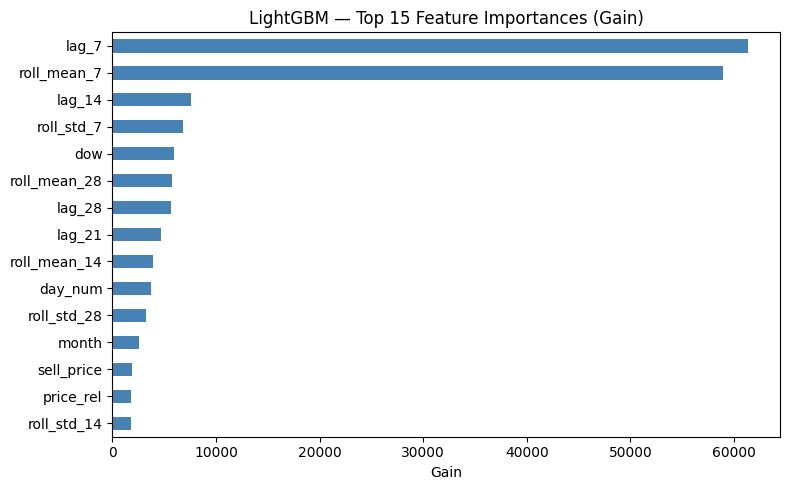


✅  LightGBM complete.


In [ ]:
#LightGBM GLOBAL MODEL
#tabular ML — learns cross-item patterns via lag features
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

#build full feature table for train+val+test 
def build_lgbm_features(df_all, top_items, lag_days=[7, 14, 21, 28],
                        rolling_windows=[7, 14, 28]):
    """
    Build a wide feature table.
    """
    df = df_all[df_all['item_id'].isin(top_items)].copy()
    df = df.sort_values(['item_id', 'day_num']).reset_index(drop=True)

    #price features 
    df['sell_price'] = df['sell_price'].astype('float32')
    df['sell_price'] = df.groupby('item_id')['sell_price'].transform(lambda x: x.ffill().bfill())
    df['price_rel']  = df.groupby('item_id')['sell_price'].transform(lambda x: x / (x.mean() + 1e-9))
    df['price_diff'] = df.groupby('item_id')['sell_price'].transform(lambda x: x.diff().fillna(0))

    #calendar features 
    df['date']      = pd.to_datetime(df['date'])
    df['dow']       = df['date'].dt.dayofweek.astype(np.int8)
    df['month']     = df['date'].dt.month.astype(np.int8)
    df['is_weekend']= (df['dow'] >= 5).astype(np.int8)
    df['dow_sin']   = np.sin(2*np.pi*df['dow']/7).astype('float32')
    df['dow_cos']   = np.cos(2*np.pi*df['dow']/7).astype('float32')
    df['month_sin'] = np.sin(2*np.pi*df['month']/12).astype('float32')
    df['month_cos'] = np.cos(2*np.pi*df['month']/12).astype('float32')
    df['event_flag']= df['event_name_1'].notna().astype(np.int8)
    type_map = {'Sporting': 1, 'National': 2, 'Cultural': 3, 'Religious': 4}
    if 'event_type_1' in df.columns:
        df['event_type_enc'] = df['event_type_1'].map(type_map).fillna(0).astype(np.int8)
    else:
        df['event_type_enc'] = 0

    #lag features 
    for lag in lag_days:
        df[f'lag_{lag}'] = df.groupby('item_id')['sales'].transform(lambda x: x.shift(lag))

    #rolling statistics (mean, std) 
    for w in rolling_windows:
        df[f'roll_mean_{w}'] = df.groupby('item_id')['sales'].transform(
            lambda x: x.shift(7).rolling(w, min_periods=1).mean())
        df[f'roll_std_{w}']  = df.groupby('item_id')['sales'].transform(
            lambda x: x.shift(7).rolling(w, min_periods=1).std().fillna(0))

    #item encoding
    le = LabelEncoder()
    df['item_enc'] = le.fit_transform(df['item_id']).astype(np.int8)

    feature_cols = (
        ['snap_CA', 'event_flag', 'event_type_enc',
         'sell_price', 'price_rel', 'price_diff',
         'dow', 'month', 'is_weekend',
         'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
         'item_enc', 'day_num'] +
        [f'lag_{lag}' for lag in lag_days] +
        [f'roll_mean_{w}' for w in rolling_windows] +
        [f'roll_std_{w}'  for w in rolling_windows]
    )
    return df, feature_cols


#build features on train+val+test together (lag features need history)
df_all = pd.concat([train, val, test], ignore_index=True)
df_feat, FEAT_COLS = build_lgbm_features(df_all, top_10_items)

#Train / Val split from feature table 
df_feat_tr  = df_feat[df_feat['day_num'] <= TRAIN_END].dropna(subset=FEAT_COLS)
df_feat_val = df_feat[(df_feat['day_num'] >= VAL_START) & (df_feat['day_num'] <= VAL_END)].dropna(subset=FEAT_COLS)
df_feat_te  = df_feat[(df_feat['day_num'] >= TEST_START)].dropna(subset=FEAT_COLS)

X_tr, y_tr   = df_feat_tr[FEAT_COLS], df_feat_tr['sales']
X_val_lgb, y_val_lgb = df_feat_val[FEAT_COLS], df_feat_val['sales']
X_te         = df_feat_te[FEAT_COLS]

print(f'  Train rows: {len(X_tr):,}   Val rows: {len(X_val_lgb):,}   Features: {len(FEAT_COLS)}')

#train LightGBM with early stoppin
lgb_train = lgb.Dataset(X_tr, label=y_tr, free_raw_data=False)
lgb_val   = lgb.Dataset(X_val_lgb, label=y_val_lgb, reference=lgb_train, free_raw_data=False)

lgb_params = {
    'objective':       'regression_l1',   # MAE loss — robust to outliers
    'metric':          ['rmse', 'mae'],
    'num_leaves':      63,
    'learning_rate':   0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':    5,
    'min_child_samples': 20,
    'lambda_l1':       0.1,
    'lambda_l2':       0.1,
    'verbose':         -1,
    'seed':            SEED,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=50)
]

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=callbacks,
)

#predict + evaluate 
df_feat_val['pred_lgbm'] = np.clip(lgb_model.predict(X_val_lgb), 0, None)

if 'pred_lgbm' in results_val.columns: results_val.drop(columns=['pred_lgbm'], inplace=True)
results_val = results_val.merge(
    df_feat_val[['item_id', 'day_num', 'pred_lgbm']],
    on=['item_id', 'day_num'], how='left'
)

print('\n  Model                                     RMSE         MAE')
print('  ')
calculate_metrics(results_val['y_true'], results_val['pred_lgbm'], 'LightGBM (Global, Lag+Rolling)', metrics_val)

#feature importance plot
imp = pd.Series(lgb_model.feature_importance(importance_type='gain'), index=FEAT_COLS).nlargest(15)
fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('LightGBM — Top 15 Feature Importances (Gain)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

In [9]:
#LSTM GLOBAL MODEL (PyTorch)

#TRAIN ON ALL FOODS_3 CA_1 ITEMS (~300 series, not just 10)
#global: it sees all items simultaneously
#we only predict the Top-10
#
# 2. PER-SERIES SAMPLES (one sample = one item's window)
#    → Each (window, target) pair comes from a single series.
#    The item index is passed as a feature so the model can
#    learn item-specific biases while sharing temporal weights.
#
# 3. DIRECT MULTI-STEP OUTPUT (predict all 28 days at once)
#    → No autoregressive rollout error accumulation.
#
# 4. PER-SERIES INSTANCE NORMALISATION
#    → Each window is normalised by its own mean/std before
#    feeding the LSTM (RevIN-lite). Denormalise on the way out.
#    This removes the level shift problem that breaks scalers
#    when applied across series with very different magnitudes.
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

print('=' * 60)
print('PHASE 5b — LSTM GLOBAL MODEL (PyTorch, ALL CA_1 items)')
print('=' * 60)

WIN     = 56   #look-back: 8 weeks
HORIZON = 28
EPOCHS  = 60
BATCH   = 128
LR      = 5e-4

#use ALL CA_1 items (all departments) for training - It covers every product in store CA_1 (~3,000 items)
all_items_global = sorted(df_global_lstm['item_id'].unique().tolist())
print(f'  Training on {len(all_items_global)} CA_1 items across ALL departments')
print(f'  Evaluating on Top-10 FOODS_3 items only')

#calendar covariates (day-level, identical for all items)
_ref_item = all_items_global[0]
cal_day = (
    df_global_lstm[df_global_lstm['item_id'] == _ref_item]
    .sort_values('day_num')
    [['day_num', 'date', 'snap_CA', 'event_name_1']]
    .copy()
)
cal_day['date']      = pd.to_datetime(cal_day['date'])
cal_day['dow_sin']   = np.sin(2*np.pi*cal_day['date'].dt.dayofweek / 7).astype('float32')
cal_day['dow_cos']   = np.cos(2*np.pi*cal_day['date'].dt.dayofweek / 7).astype('float32')
cal_day['month_sin'] = np.sin(2*np.pi*cal_day['date'].dt.month / 12).astype('float32')
cal_day['month_cos'] = np.cos(2*np.pi*cal_day['date'].dt.month / 12).astype('float32')
cal_day['event']     = cal_day['event_name_1'].notna().astype('float32')
cal_day = cal_day.set_index('day_num')
CAL_COLS = ['snap_CA', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'event']
cal_arr  = cal_day[CAL_COLS].values.astype('float32')  
all_days = cal_day.index.values                         

#build per-item sales arrays 
print('  Building per-item sales arrays (pivot)...', end=' ')
pivot_global = (
    df_global_lstm
    .pivot_table(index='day_num', columns='item_id', values='sales', aggfunc='sum')
    .reindex(all_days)
    .fillna(0)
    .astype('float32')
)
#align column order to all_items_global
pivot_global = pivot_global.reindex(columns=all_items_global, fill_value=0)
sales_matrix = pivot_global.values   # (T, N_items) — fast numpy access
sales_by_item = {item: sales_matrix[:, j] for j, item in enumerate(all_items_global)}
print(f'done  shape={sales_matrix.shape}')
del pivot_global; gc.collect()

#item index encoding
item2idx      = {item: i for i, item in enumerate(all_items_global)}
N_ITEMS_TOTAL = len(all_items_global)

#day position lookup
day2pos       = {int(d): i for i, d in enumerate(all_days)}
train_end_pos = day2pos[TRAIN_END]
val_end_pos   = day2pos[VAL_END]

print(f'  Timesteps: {len(all_days)}   Items: {N_ITEMS_TOTAL}   Train ends at pos: {train_end_pos}')

#PyTorch Dataset 
class SeriesWindowDataset(Dataset):
    """
    Each sample: one sliding window from one series.
    Input  (WIN, 7): [norm_sales, snap, dow_sin, dow_cos, month_sin, month_cos, event]
    Target (HORIZON,): normalised future sales.

    RevIN-lite instance normalisation:
      norm = (x - mean(window)) / (std(window) + eps)
    I
    """
    MIN_STD = 0.5   # minimum std 

    def __init__(self, items, sales_dict, cal, end_pos, win=WIN, horizon=HORIZON):
        self.samples = []
        for item in items:
            s   = sales_dict[item].astype(np.float32)   #float32
            idx = item2idx[item]
            for t in range(win, end_pos - horizon + 2):
                x_sales = s[t - win : t]               # (WIN,)  float32
                y_sales = s[t : t + horizon]           # (HORIZON,) float32
                x_cal   = cal[t - win : t]             # (WIN, 6) float32

                # RevIN-lite: use window mean & std as normalisation stats
                mu  = float(x_sales.mean())
                sig = float(max(x_sales.std(), self.MIN_STD))

                x_norm = ((x_sales - mu) / sig).reshape(-1, 1).astype(np.float32)
                y_norm = np.clip((y_sales - mu) / sig, -10.0, 10.0).astype(np.float32)
                feat   = np.hstack([x_norm, x_cal]).astype(np.float32)  # (WIN, 7)
                self.samples.append((feat, y_norm, idx, np.float32(mu), np.float32(sig)))

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i):
        feat, y, idx, mu, sig = self.samples[i]
        return (torch.from_numpy(feat),          # (WIN, 7)   float32
                torch.from_numpy(y),             # (HORIZON,) float32
                torch.tensor(idx, dtype=torch.long),
                torch.tensor(float(mu),  dtype=torch.float32),
                torch.tensor(float(sig), dtype=torch.float32))

train_ds = SeriesWindowDataset(all_items_global, sales_by_item, cal_arr, train_end_pos)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                      drop_last=True, num_workers=0, pin_memory=False)
print(f'  Training samples: {len(train_ds):,}   Batches/epoch: {len(train_dl)}')

#Model 
class GlobalLSTM(nn.Module):
    def __init__(self, n_feats=7, n_items=N_ITEMS_TOTAL,
                 emb_dim=8, hidden=128, n_layers=2, dropout=0.25, horizon=HORIZON):
        super().__init__()
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.lstm = nn.LSTM(n_feats + emb_dim, hidden, n_layers,
                            batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, horizon),
        )

    def forward(self, x, item_idx):
        # x: (B, WIN, n_feats)   item_idx: (B,)
        emb = self.item_emb(item_idx).unsqueeze(1).expand(-1, x.size(1), -1)  # (B, WIN, emb_dim)
        x   = torch.cat([x, emb], dim=-1)                                      # (B, WIN, n_feats+emb_dim)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])   # (B, HORIZON)

model_lstm = GlobalLSTM().to(DEVICE)
n_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f'  Model parameters: {n_params:,}')

optimiser = torch.optim.AdamW(model_lstm.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimiser, max_lr=LR, steps_per_epoch=len(train_dl), epochs=EPOCHS, pct_start=0.1)
criterion = nn.HuberLoss(delta=1.0)

#Training loop 
print(f'\n  Training {EPOCHS} epochs...')
for ep in range(1, EPOCHS + 1):
    model_lstm.train()
    ep_loss = 0.0
    for xb, yb, ib, _, _ in train_dl:
        xb, yb, ib = xb.to(DEVICE), yb.to(DEVICE), ib.to(DEVICE)
        optimiser.zero_grad()
        pred = model_lstm(xb, ib)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimiser.step()
        scheduler.step()
        ep_loss += loss.item()
    if ep % 10 == 0:
        print(f'    Epoch {ep:3d}/{EPOCHS}  Loss={ep_loss/len(train_dl):.6f}  LR={scheduler.get_last_lr()[0]:.2e}')

#Inference on Top-10 items (validation set) 
model_lstm.eval()

def lstm_predict(items, end_pos_excl):
    """
    Predict HORIZON days starting at end_pos_excl for each item in items.
    end_pos_excl: position of first day we want to predict (0-indexed in all_days).
    """
    rows = []
    with torch.no_grad():
        for item in items:
            s      = sales_by_item[item]
            x_sales = s[end_pos_excl - WIN : end_pos_excl]     # (WIN,)
            x_cal   = cal_arr[end_pos_excl - WIN : end_pos_excl]  # (WIN, 6)
            mu  = float(x_sales.mean())
            sig = float(max(x_sales.std(), 0.5))   # same MIN_STD as training
            x_norm = ((x_sales - mu) / sig).reshape(-1, 1).astype(np.float32)
            feat   = np.hstack([x_norm, x_cal]).astype(np.float32)  # (WIN, 7)
            xb  = torch.from_numpy(feat).unsqueeze(0).to(DEVICE)      # (1, WIN, 7)
            ib  = torch.tensor([item2idx[item]], dtype=torch.long).to(DEVICE)
            out = model_lstm(xb, ib).squeeze(0).cpu().numpy()          # (HORIZON,)
            # Denormalise
            fc  = np.clip(out * sig + mu, 0, None)
            target_days = all_days[end_pos_excl : end_pos_excl + HORIZON]
            for d, v in zip(target_days, fc):
                rows.append({'item_id': item, 'day_num': int(d), 'pred_lstm': float(v)})
    return pd.DataFrame(rows)

#validation: predict days VAL_START…VAL_END
val_start_pos = day2pos[VAL_START]
df_lstm_val = lstm_predict(top_10_items, val_start_pos)

if 'pred_lstm' in results_val.columns: results_val.drop(columns=['pred_lstm'], inplace=True)
results_val = results_val.merge(df_lstm_val, on=['item_id', 'day_num'], how='left')

print('\n  Model                                     RMSE         MAE')
print('  ')
calculate_metrics(results_val['y_true'], results_val['pred_lstm'], 'LSTM Global (PyTorch, all FOODS_3)', metrics_val)


Using device: cuda
PHASE 5b — LSTM GLOBAL MODEL (PyTorch, ALL CA_1 items)
  Training on 3049 CA_1 items across ALL departments
  Evaluating on Top-10 FOODS_3 items only
  Building per-item sales arrays (pivot)... done  shape=(1941, 3049)
  Timesteps: 1941   Items: 3049   Train ends at pos: 1884
  Building training dataset (all CA_1 items × sliding windows, MIN_STD=0.5)...
  Training samples: 5,494,298   Batches/epoch: 42924
  Model parameters: 240,804

  Training 60 epochs...
    Epoch  10/60  Loss=0.296700  LR=4.93e-04
    Epoch  20/60  Loss=0.289071  LR=4.22e-04
    Epoch  30/60  Loss=0.285229  LR=2.93e-04
    Epoch  40/60  Loss=0.282586  LR=1.51e-04
    Epoch  50/60  Loss=0.280928  LR=4.11e-05
    Epoch  60/60  Loss=0.280432  LR=2.00e-09

  Model                                     RMSE         MAE
  ----------------------------------------------------------
  LSTM Global (PyTorch, all FOODS_3)        RMSE=13.9810   MAE= 8.8290

✅  LSTM complete.



  VALIDATION SET (28 days):
                                Model    RMSE     MAE
1      LightGBM (Global, Lag+Rolling) 13.0259  8.1756
2             SARIMA (1,1,1)(1,1,1,7) 13.5296  8.4664
3        SARIMAX (Feature-Engineered) 13.9419  9.0868
4  LSTM Global (PyTorch, all FOODS_3) 13.9810  8.8290
5         Holt-Winters (Add+Add, m=7) 15.8334  9.9420
6                      Seasonal Naïve 18.5143 10.3857
7                               Naïve 29.1298 19.8750


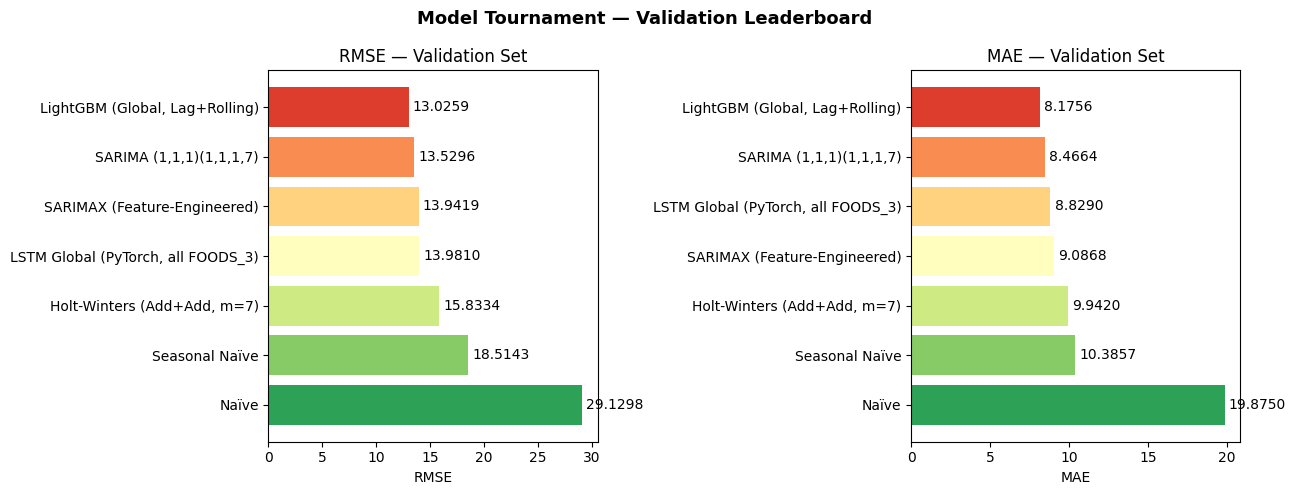

In [10]:
#MODEL TOURNAMENT — VALIDATION SUMMARY

#dataframe from stored metrics
df_leaderboard_val = pd.DataFrame(metrics_val).T.reset_index().rename(columns={'index': 'Model'})
df_leaderboard_val = df_leaderboard_val.sort_values('RMSE').reset_index(drop=True)
df_leaderboard_val.index += 1

print('\n  VALIDATION SET (28 days):')
print(df_leaderboard_val.to_string())

#leaderboard
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette('RdYlGn_r', len(df_leaderboard_val))

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    vals = df_leaderboard_val.set_index('Model')[metric].sort_values()
    bars = ax.barh(vals.index, vals.values, color=colors[::-1])
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} — Validation Set')
    ax.invert_yaxis()

plt.suptitle('Model Tournament — Validation Leaderboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
#FINAL EVALUATION ON TEST SET 

print('FINAL TEST SET EVALUATION (Days 1914-1941)')

#Seasonal Naïve on test 
calculate_metrics(results_test['y_true'], results_test['pred_naive'],  'Naïve',          metrics_test)
calculate_metrics(results_test['y_true'], results_test['pred_snaive'], 'Seasonal Naïve', metrics_test)

#Holt-Winters on test 
from statsmodels.tsa.holtwinters import ExponentialSmoothing

preds_hw_test = []
train_val_hw  = pd.concat([train, val], ignore_index=True)
for item in top_10_items:
    y_tv = train_val_hw[train_val_hw['item_id'] == item].sort_values('day_num')['sales'].values.astype(float)
    try:
        hw = ExponentialSmoothing(y_tv, trend='add', seasonal='add',
                                  seasonal_periods=7, initialization_method='estimated').fit(optimized=True)
        fc = np.clip(hw.forecast(28), 0, None)
    except Exception:
        hw = ExponentialSmoothing(y_tv, seasonal='add', seasonal_periods=7).fit()
        fc = np.clip(hw.forecast(28), 0, None)
    preds_hw_test.append(pd.DataFrame({'item_id': item, 'day_num': range(TEST_START, TEST_END+1), 'pred_hw': fc}))

df_hw_test = pd.concat(preds_hw_test, ignore_index=True)
if 'pred_hw' in results_test.columns: results_test.drop(columns=['pred_hw'], inplace=True)
results_test = results_test.merge(df_hw_test, on=['item_id', 'day_num'], how='left')
calculate_metrics(results_test['y_true'], results_test['pred_hw'], 'Holt-Winters (Add+Add, m=7)', metrics_test)

#SARIMA on test 
from statsmodels.tsa.statespace.sarimax import SARIMAX

preds_sarima_test = []
for item in top_10_items:
    y_tv = train_val_hw[train_val_hw['item_id'] == item].sort_values('day_num')['sales'].values.astype(float)
    mdl  = SARIMAX(y_tv, order=(1,1,1), seasonal_order=(1,1,1,7),
                   enforce_stationarity=False, enforce_invertibility=False)
    fit  = mdl.fit(disp=False)
    fc   = np.clip(fit.forecast(28), 0, None)
    preds_sarima_test.append(pd.DataFrame({'item_id': item, 'day_num': range(TEST_START, TEST_END+1), 'pred_sarima': fc}))

df_sarima_test = pd.concat(preds_sarima_test, ignore_index=True)
if 'pred_sarima' in results_test.columns: results_test.drop(columns=['pred_sarima'], inplace=True)
results_test = results_test.merge(df_sarima_test, on=['item_id', 'day_num'], how='left')
calculate_metrics(results_test['y_true'], results_test['pred_sarima'], 'SARIMA (1,1,1)(1,1,1,7)', metrics_test)

#SARIMAX on test ───────────────────────────────────────
#Retrain on train+val, forecast test.
#build_exog uses ITEM_PRICE_STATS (train-based) → consistent with val phase.
train_val_sarimax = pd.concat([train, val], ignore_index=True)
preds_sarimax_test = []
for item in top_10_items:
    df_tv  = train_val_sarimax[train_val_sarimax['item_id'] == item].sort_values('day_num')
    df_te  = test[test['item_id'] == item].sort_values('day_num')
    y_tv   = df_tv['sales'].values.astype(float)
    X_tv   = build_exog(df_tv, item_id=item)   #train-based normalisation
    X_te_  = build_exog(df_te, item_id=item)   #same train-based normalisation
    mdl    = SARIMAX(y_tv, exog=X_tv, order=(1,1,1), seasonal_order=(1,1,1,7),
                     enforce_stationarity=False, enforce_invertibility=False)
    fit    = mdl.fit(disp=False)
    fc     = np.clip(fit.forecast(28, exog=X_te_), 0, None)
    preds_sarimax_test.append(pd.DataFrame({'item_id': item, 'day_num': range(TEST_START, TEST_END+1), 'pred_sarimax': fc}))

df_sarimax_test = pd.concat(preds_sarimax_test, ignore_index=True)
if 'pred_sarimax' in results_test.columns: results_test.drop(columns=['pred_sarimax'], inplace=True)
results_test = results_test.merge(df_sarimax_test, on=['item_id', 'day_num'], how='left')
calculate_metrics(results_test['y_true'], results_test['pred_sarimax'], 'SARIMAX (Feature-Engineered)', metrics_test)

#LightGBM on test 
df_feat_te_final = df_feat[(df_feat['day_num'] >= TEST_START)].dropna(subset=FEAT_COLS).copy()
df_feat_te_final = df_feat_te_final[df_feat_te_final['item_id'].isin(top_10_items)]
df_feat_te_final['pred_lgbm'] = np.clip(lgb_model.predict(df_feat_te_final[FEAT_COLS]), 0, None)
if 'pred_lgbm' in results_test.columns: results_test.drop(columns=['pred_lgbm'], inplace=True)
results_test = results_test.merge(
    df_feat_te_final[['item_id', 'day_num', 'pred_lgbm']],
    on=['item_id', 'day_num'], how='left'
)
calculate_metrics(results_test['y_true'], results_test['pred_lgbm'], 'LightGBM (Global, Lag+Rolling)', metrics_test)

#LSTM on test 
#sales_by_item already contains val+test data.
#move the window anchor to TEST_START.
test_start_pos = day2pos[TEST_START]
df_lstm_te = lstm_predict(top_10_items, test_start_pos)

if 'pred_lstm' in results_test.columns: results_test.drop(columns=['pred_lstm'], inplace=True)
results_test = results_test.merge(df_lstm_te, on=['item_id', 'day_num'], how='left')
calculate_metrics(results_test['y_true'], results_test['pred_lstm'], 'LSTM Global (PyTorch, all FOODS_3)', metrics_test)


FINAL TEST SET EVALUATION (Days 1914-1941)
  Naïve                                     RMSE=25.5938   MAE=18.0071
  Seasonal Naïve                            RMSE=13.9249   MAE= 8.4893
  Holt-Winters (Add+Add, m=7)               RMSE= 9.1050   MAE= 5.8116
  SARIMA (1,1,1)(1,1,1,7)                   RMSE= 9.0587   MAE= 5.6668


/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mattarluu/4/AML/venvAML/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mattarluu/4/AML/venvAML/lib/py

  SARIMAX (Feature-Engineered)              RMSE= 8.9840   MAE= 5.5587
  LightGBM (Global, Lag+Rolling)            RMSE= 9.4989   MAE= 6.2224
  LSTM Global (PyTorch, all FOODS_3)        RMSE= 9.9224   MAE= 6.5503


(np.float64(9.922416412327605), 6.550348811170885)

FINAL MODEL TOURNAMENT — TEST SET LEADERBOARD

                                 Model    RMSE     MAE  RMSE_reduction_%
1        SARIMAX (Feature-Engineered)  8.9840  5.5587           35.4800
2             SARIMA (1,1,1)(1,1,1,7)  9.0587  5.6668           34.9500
3         Holt-Winters (Add+Add, m=7)  9.1050  5.8116           34.6100
4      LightGBM (Global, Lag+Rolling)  9.4989  6.2224           31.7800
5  LSTM Global (PyTorch, all FOODS_3)  9.9224  6.5503           28.7400
6                      Seasonal Naïve 13.9249  8.4893            0.0000
7                               Naïve 25.5938 18.0071          -83.8000


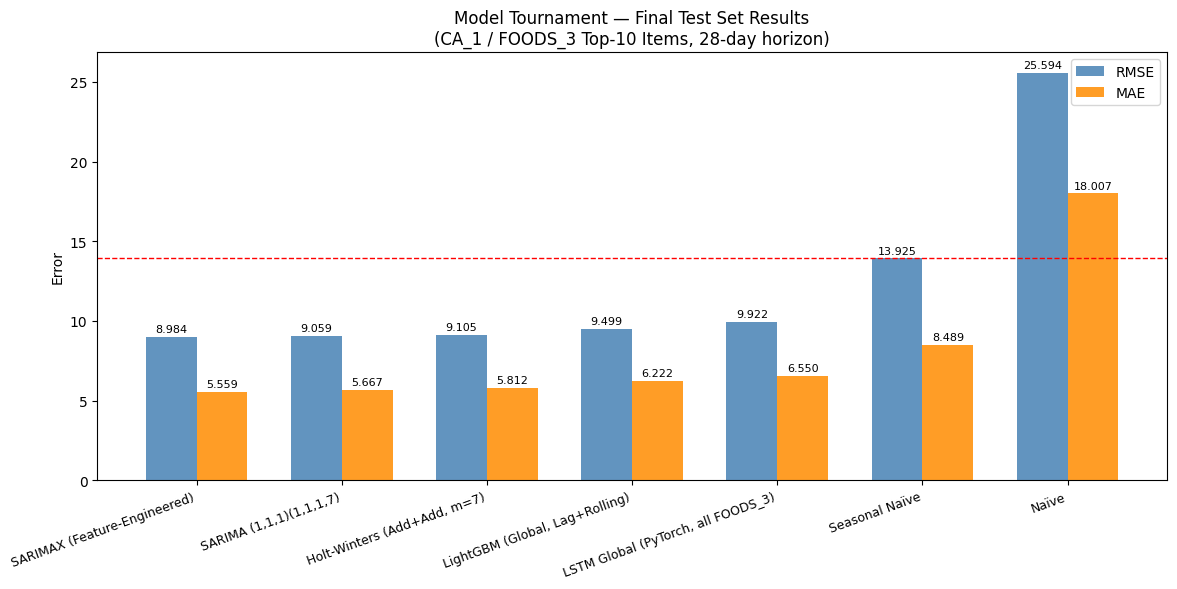


Per-item RMSE breakdown for best model: SARIMAX (Feature-Engineered)
               RMSE     MAE
item_id                    
FOODS_3_808  0.7829  0.3624
FOODS_3_541  1.0991  0.3589
FOODS_3_555  5.1320  3.5746
FOODS_3_080  5.6667  4.2349
FOODS_3_714  6.1317  5.3209
FOODS_3_586  7.3816  5.5037
FOODS_3_252  8.7875  7.0610
FOODS_3_587  9.1698  6.8051
FOODS_3_120 15.5437  9.8989
FOODS_3_090 15.8701 12.4668


In [12]:
#LEADERBOARD & ANALYSIS
print('FINAL MODEL TOURNAMENT — TEST SET LEADERBOARD')

df_final_lb = pd.DataFrame(metrics_test).T.reset_index().rename(columns={'index': 'Model'})
df_final_lb = df_final_lb.sort_values('RMSE').reset_index(drop=True)
df_final_lb.index += 1

#Compute RMSE reduction vs Seasonal Naïve baseline
baseline_rmse = df_final_lb[df_final_lb['Model'] == 'Seasonal Naïve']['RMSE'].values[0]
df_final_lb['RMSE_reduction_%'] = ((baseline_rmse - df_final_lb['RMSE']) / baseline_rmse * 100).round(2)

print('\n', df_final_lb.to_string(index=True))
#Grouped bar chart 
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_final_lb))
w = 0.35
bars1 = ax.bar(x - w/2, df_final_lb['RMSE'], w, label='RMSE', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, df_final_lb['MAE'],  w, label='MAE',  color='darkorange', alpha=0.85)
ax.bar_label(bars1, fmt='%.3f', fontsize=8, padding=2)
ax.bar_label(bars2, fmt='%.3f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(df_final_lb['Model'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Error')
ax.set_title('Model Tournament — Final Test Set Results\n(CA_1 / FOODS_3 Top-10 Items, 28-day horizon)', fontsize=12)
ax.legend()
ax.axhline(baseline_rmse, color='red', ls='--', lw=1, label=f'Seasonal Naïve RMSE = {baseline_rmse:.3f}')
plt.tight_layout()
plt.show()

#Per-item breakdown for best model 
best_model_col = 'pred_' + {
    'LightGBM (Global, Lag+Rolling)':       'lgbm',
    'LSTM Global (PyTorch, all FOODS_3)':    'lstm',
    'SARIMAX (Feature-Engineered)':          'sarimax',
    'SARIMA (1,1,1)(1,1,1,7)':               'sarima',
    'Holt-Winters (Add+Add, m=7)':           'hw',
    'Seasonal Naïve':                        'snaive',
    'Naïve':                                 'naive',
}.get(df_final_lb.iloc[0]['Model'], 'lgbm')

print(f'\nPer-item RMSE breakdown for best model: {df_final_lb.iloc[0]["Model"]}')
per_item = (
    results_test.groupby('item_id')
    .apply(lambda g: pd.Series({
        'RMSE': np.sqrt(mean_squared_error(g['y_true'], g[best_model_col].fillna(0))),
        'MAE':  mean_absolute_error(g['y_true'], g[best_model_col].fillna(0))
    }))
    .sort_values('RMSE')
)
print(per_item.to_string())


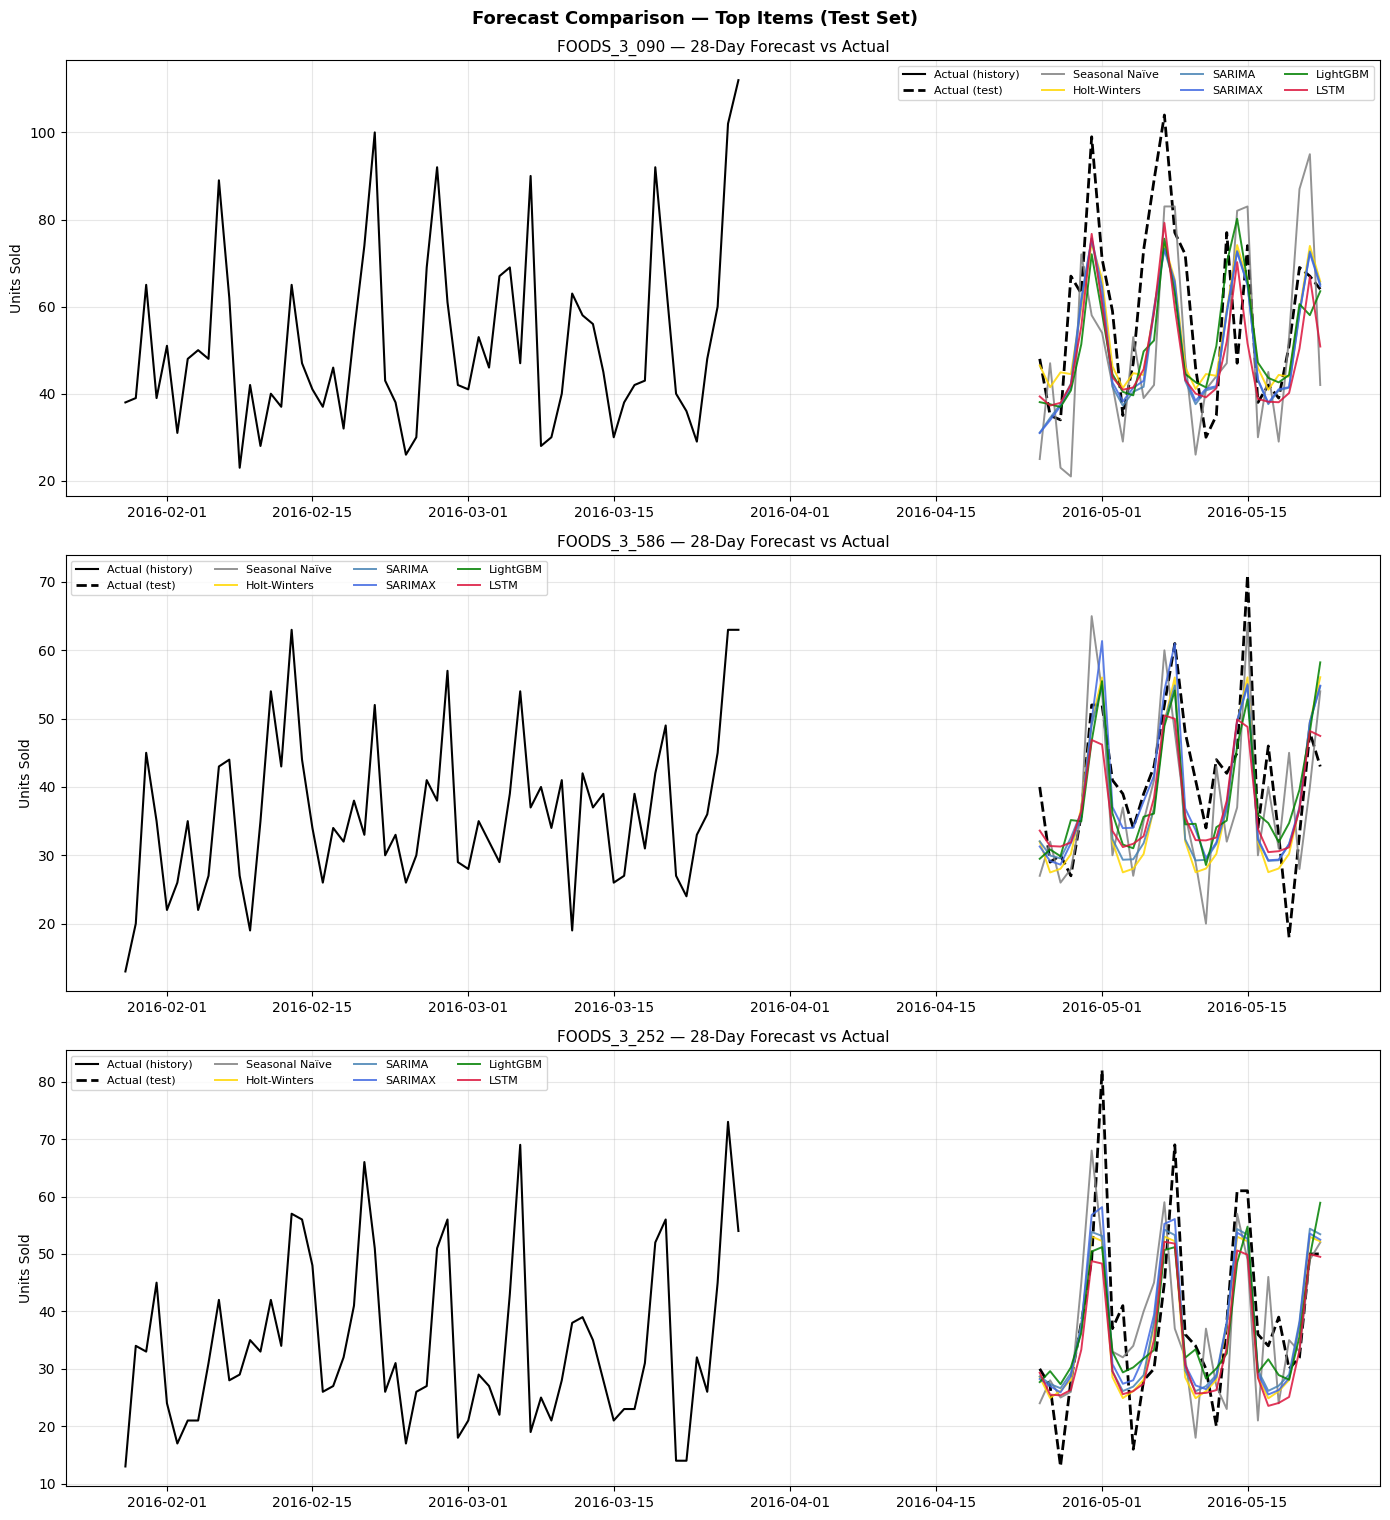

In [ ]:
#FORECAST VISUALISATION (top 3 items)
n_plot = 3
items_to_plot = top_10_items[:n_plot]

pred_cols = {
    'Seasonal Naïve': 'pred_snaive',
    'Holt-Winters':   'pred_hw',
    'SARIMA':         'pred_sarima',
    'SARIMAX':        'pred_sarimax',
    'LightGBM':       'pred_lgbm',
    'LSTM':           'pred_lstm',
}
colors_map = {
    'Seasonal Naïve': 'grey',
    'Holt-Winters':   'gold',
    'SARIMA':         'steelblue',
    'SARIMAX':        'royalblue',
    'LightGBM':       'green',
    'LSTM':           'crimson',
}

fig, axes = plt.subplots(n_plot, 1, figsize=(14, 5 * n_plot), sharex=False)
if n_plot == 1: axes = [axes]

for ax, item in zip(axes, items_to_plot):
    #Context: last 60 train days
    hist = train[train['item_id'] == item].sort_values('day_num').tail(60)
    test_item = results_test[results_test['item_id'] == item].sort_values('day_num')

    #Combine for x-axis
    ax.plot(hist['date'], hist['sales'], color='black', lw=1.5, label='Actual (history)')
    ax.plot(test_item['date'], test_item['y_true'], color='black', lw=2.0, ls='--', label='Actual (test)')

    for name, col in pred_cols.items():
        if col in test_item.columns and test_item[col].notna().any():
            ax.plot(test_item['date'], test_item[col], lw=1.4,
                    color=colors_map[name], ls='-', label=name, alpha=0.85)

    ax.set_title(f'{item} — 28-Day Forecast vs Actual', fontsize=11)
    ax.set_ylabel('Units Sold')
    ax.legend(fontsize=8, ncol=4)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Forecast Comparison — Top Items (Test Set)', y=1.01, fontsize=13, fontweight='bold')
plt.show()